# Convolutional Neural Nets

In [1]:
# Import Libraries
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(X_train, y_train), (X_test, y_test) =  keras.datasets.cifar10.load_data() # load data

In [3]:
X_train.shape, X_test.shape # 32 * 32 pixels with tensor 3(RGB)

((50000, 32, 32, 3), (10000, 32, 32, 3))

In [4]:
y_train = y_train.reshape(-1,) # flattening out the array

Display Image

In [5]:
classes = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "house",
           "ship", "truck"]

In [6]:
def number(index):
    print(index)
    plt.figure(figsize=(15,2))
    plt.imshow(X_train[index])
    print("---" * 15)
    print(f"The image is {classes[y_train[index]]}")
    print("---" * 15)

17475
---------------------------------------------
The image is automobile
---------------------------------------------


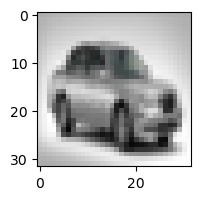

In [7]:
import random
index = random.randrange(0, 50000)
number(index)

Data Split

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, random_state=51, test_size=0.1)

In [9]:
X_train.shape, X_val.shape

((45000, 32, 32, 3), (5000, 32, 32, 3))

Converting labels into a 1D array

In [10]:
# y_train = y_train.reshape(-1,)

In [11]:
y_val = y_val.reshape(-1,)

In [12]:
y_test = y_test.reshape(-1,)

Normalization

In [13]:
X_train = X_train / 255
X_val = X_val / 255
X_test = X_test / 255

In [14]:
X_train[0].shape

(32, 32, 3)

ANN

In [15]:
model = keras.Sequential([
    layers.Flatten(input_shape=(32, 32, 3)),
    layers.Dense(3000, activation="relu"),
    layers.Dense(1000, activation="relu"),
    layers.Dense(10, activation="softmax")
])

In [16]:
model.compile(optimizer="rmsprop", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [21]:
model.fit(X_train, y_train, epochs=5, validation_data=(X_val, y_val), batch_size=256)

Epoch 1/5
176/176 [==============================] - 21s 117ms/step - loss: 1.7631 - accuracy: 0.3677 - val_loss: 1.7715 - val_accuracy: 0.3666
Epoch 2/5
176/176 [==============================] - 19s 111ms/step - loss: 1.7006 - accuracy: 0.3921 - val_loss: 1.7870 - val_accuracy: 0.3706
Epoch 3/5
176/176 [==============================] - 21s 121ms/step - loss: 1.6554 - accuracy: 0.4105 - val_loss: 1.6403 - val_accuracy: 0.4214
Epoch 4/5
176/176 [==============================] - 21s 120ms/step - loss: 1.6175 - accuracy: 0.4240 - val_loss: 1.5870 - val_accuracy: 0.4480
Epoch 5/5
176/176 [==============================] - 21s 119ms/step - loss: 1.5647 - accuracy: 0.4430 - val_loss: 1.6427 - val_accuracy: 0.4284


In [22]:
model.evaluate(X_test, y_test)

313/313 [==============================] - 3s 9ms/step - loss: 1.6450 - accuracy: 0.4278


[1.6450494527816772, 0.4277999997138977]

CNN

In [23]:
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3), padding="same"),
    layers.Dropout(0.2),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.Dropout(0.5),
    layers.MaxPool2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

In [24]:
model.compile(optimizer="rmsprop", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [26]:
model.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val), batch_size=256)

Epoch 1/10
176/176 [==============================] - 42s 236ms/step - loss: 1.5262 - accuracy: 0.4578 - val_loss: 1.5812 - val_accuracy: 0.4914
Epoch 2/10
176/176 [==============================] - 39s 224ms/step - loss: 1.3354 - accuracy: 0.5292 - val_loss: 1.4157 - val_accuracy: 0.5700
Epoch 3/10
176/176 [==============================] - 39s 221ms/step - loss: 1.2059 - accuracy: 0.5735 - val_loss: 1.3260 - val_accuracy: 0.5946
Epoch 4/10
176/176 [==============================] - 39s 221ms/step - loss: 1.1162 - accuracy: 0.6092 - val_loss: 1.2867 - val_accuracy: 0.6004
Epoch 5/10
176/176 [==============================] - 41s 234ms/step - loss: 1.0466 - accuracy: 0.6350 - val_loss: 1.1911 - val_accuracy: 0.6162
Epoch 6/10
176/176 [==============================] - 40s 225ms/step - loss: 1.0041 - accuracy: 0.6490 - val_loss: 1.1255 - val_accuracy: 0.6574
Epoch 7/10
176/176 [==============================] - 39s 220ms/step - loss: 0.9548 - accuracy: 0.6658 - val_loss: 1.1188 - val_ac

In [27]:
model.evaluate(X_test, y_test)

313/313 [==============================] - 4s 14ms/step - loss: 1.0443 - accuracy: 0.6700


[1.0443203449249268, 0.6700000166893005]